Define the default font sizes to make the figures prettier:

In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import jaxfilter, jaxfixedpt
from scipy import signal
import jax
import jax.numpy as jnp

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)


In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "lms"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

### 3.6.1 Analytical Examples
Some analytical tools presented so far are employed to characterize two interesting types of adaptive filtering problems. The
problems are also solved with the LMS algorithm.

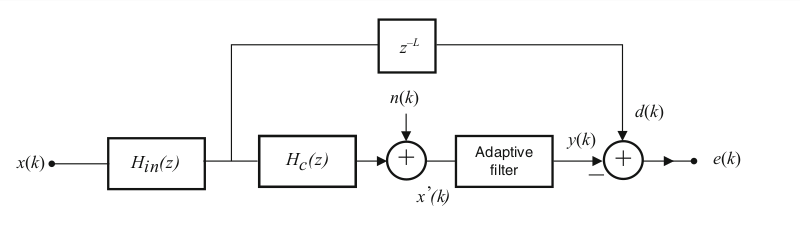

Example 3.1 A Gaussian white-noise sequence (variance $\sigma_{n_1}^2 = 1$) is first colored by

$$
H_{in}(z) = \frac{1}{z - 0.5}
$$

then sent through a communication channel

$$
H_c(z) = \frac{1}{z + 0.8}
$$

and additive channel noise of variance $\sigma_n^2 = 0.1$ is added. The desired signal $d(k)$ is produced by passing the same white noise source through $H_{in}(z)$ and delaying by $L$ samples. We build an adaptive two-tap FIR equalizer (so $M = 2$ taps, i.e., 2 coefficients $w_0, w_1$) and must:

(a) find the best delay $L$,
(b) compute the Wiener solution $w_o$,
(c) choose an appropriate $\mu$ and describe the convergence path,
(d) plot / describe learning curves (single-run and averaged).

#### (a) Choose the best delay $L$

We examine the cross-correlation between the adaptive filter input $x'(k)$ (the channel output) and the desired $d(k)$:

$$
p(i) = E[d(k) \cdot x'(k - i)]
$$

By computing $p(0)$ for small candidate delays $L$ (via contour/residue integration as in the book), the strongest correlation occurs for $L = 1$. In other words, the desired is best aligned with the channel output when delayed by one sample. 

#### (b) Compute the Wiener (optimal) solution

From the book's residue calculations the relevant correlation values (for the two-tap equalizer, i.e. $w = [w_0, w_1]^T$) are:

Cross-correlation vector (for $L = 1$):
$$
p = \begin{bmatrix} p(0) \\ p(1) \end{bmatrix} = \begin{bmatrix} 0.9524 \\ 0.4762 \end{bmatrix}.
$$

Autocorrelation elements of the adaptive filter input $x(k)$ are:
$$
r(0) = 1.6873,
$$
$$
r(1) = -0.7937.
$$

The 2 × 2 input autocorrelation matrix is
$$
R = \begin{bmatrix} 1.6873 & -0.7937 \\ -0.7937 & 1.6873 \end{bmatrix}.
$$

The Wiener (minimum-MSE) solution is
$$
w_o = R^{-1} p.
$$

Carrying out the 2×2 inversion and multiplication (book's values) gives
$$
w_o \approx \begin{bmatrix} 0.8953 \\ 0.7034 \end{bmatrix}.
$$

So the optimal 2-tap equalizer coefficients are approximately
$w_0 = 0.8953$, $w_1 = 0.7034$.

#### (c) Choose $\mu$ and describe convergence path

The book recommends choosing a relatively small step to get a smooth (noisy but stable) path. They used

Step size $\mu$:
$$
\mu = \frac{1}{40 \cdot \text{tr}[R]}.
$$

Here $\text{tr}[R] = 1.6873 + 1.6873 = 3.3746$, so

$$
\mu = \frac{1}{40 \cdot 3.3746} \approx 0.0074.
$$

=== Example 3.1 Channel Equalization ===
Wiener solution: [0.89446074 0.70148533]
R: [[ 1.68526315 -0.78695531]
 [-0.78695531  1.68526315]]
p: [0.95536413 0.47828676]
Final coefficients: [0.88871639 0.69650673]
Final MSE: 0.300362
Final coeff error: 0.029765

=== CONVERGENCE ANALYSIS (Ensemble Average) ===
Total iterations: 701
Initial coefficients: w0=0.0000, w1=0.0000
Final coefficients: w0=0.8887, w1=0.6965
Wiener solution: w0=0.8945, w1=0.7015
Final distance to Wiener solution: 0.007602
Total path length: 1.3645
Average step size: 0.001949


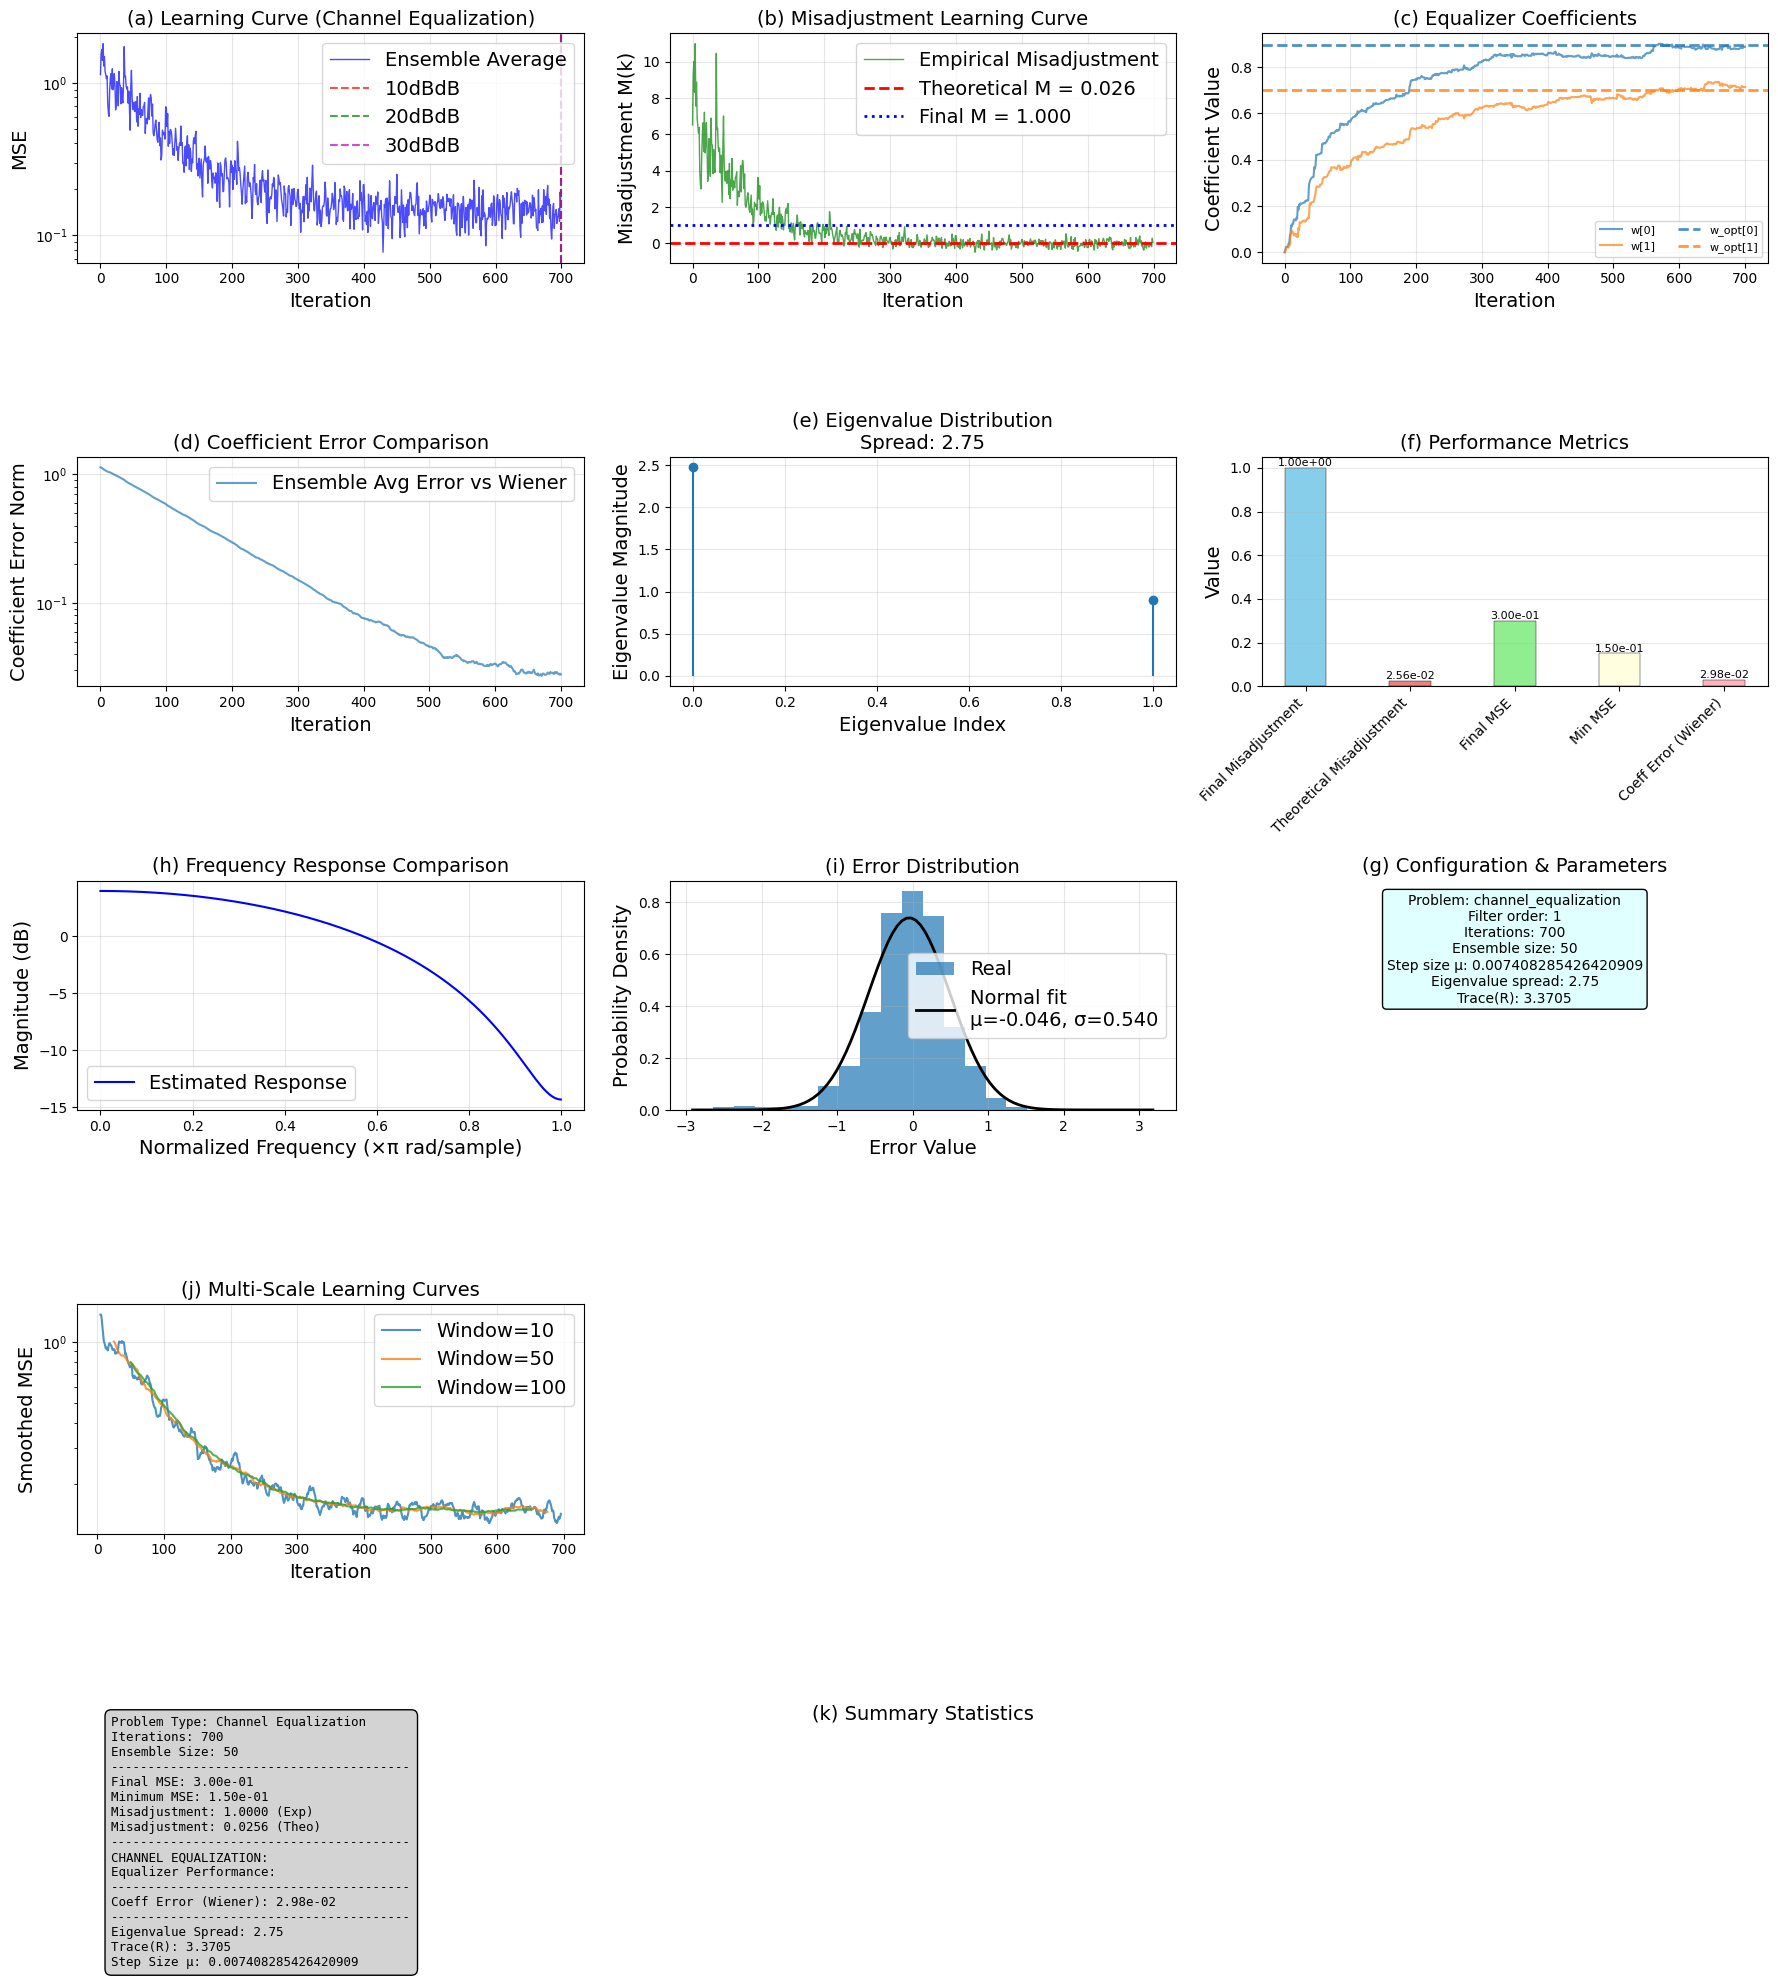

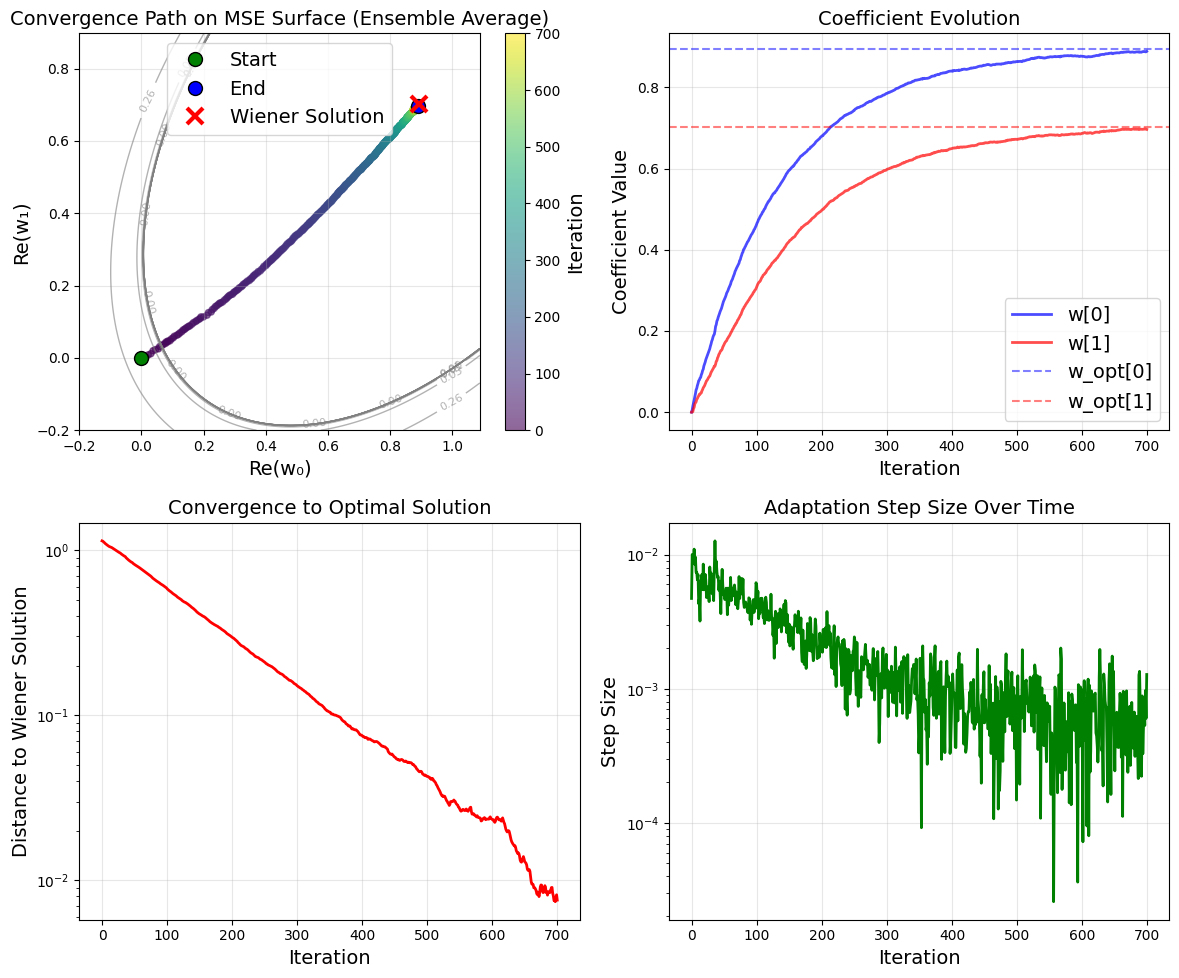

In [3]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from typing import Optional, Union, Tuple, Dict, Any
# Force JAX to use float64 for better numerical agreement
jax.config.update("jax_enable_x64", True)
_Array = Union[jnp.ndarray]

# --------------------------------------------------
# Signal generator (Example 3.1)
# --------------------------------------------------
def gen_signal_ex_3_1(n_samples: int, key: jax.random.PRNGKey, delay_L: int = 0):
    """Generate input/output signals for Example 3.1 channel equalization."""
    key, subkey1, subkey2 = jax.random.split(key, 3)

    # White Gaussian noise
    u = jax.random.normal(subkey1, (n_samples + 100,), dtype=jnp.float64)

    # H_in(z) = 1 / (1 - 0.5 z^-1)
    def hin_step(carry, u_n):
        y_prev = carry
        y = 0.5 * y_prev + u_n
        return y, y
    _, x_colored = jax.lax.scan(hin_step, 0.0, u)

    # H_c(z) = 1 / (1 + 0.8 z^-1)
    def hc_step(carry, x_n):
        y_prev = carry
        y = -0.8 * y_prev + x_n
        return y, y
    _, x_chan = jax.lax.scan(hc_step, 0.0, x_colored)

    # Add channel noise
    noise = jax.random.normal(subkey2, (n_samples + 100,), dtype=jnp.float64) * jnp.sqrt(0.1)
    x_final = x_chan + noise

    # Desired signal = delayed colored input
    d = jnp.roll(x_colored, delay_L)

    # Remove transients
    return x_final[100:100+n_samples], d[100:100+n_samples]

mu = 1.0 / (40 * 3.3746)  # textbook rule
lms = jaxfilter.LMS(mu=mu, filter_order=1)
n_samples = 700
n_ensemble = 50
eq = jaxfilter.ChannelEqualization(lms, gen_signal_ex_3_1, n_ensemble=n_ensemble)

w_hist, e_hist, metrics, _ = eq.run(n_samples)
Rinv = jnp.linalg.inv(metrics['R'])
print("=== Example 3.1 Channel Equalization ===")
print(f"Wiener solution: {metrics['wiener_solution']}")
print(f"R: {metrics['R']}")
print(f"p: {metrics['p']}")
print(f"Final coefficients: {metrics['final_coeff']}")
print(f"Final MSE: {metrics['final_mse']:.6f}")
print(f"Final coeff error: {metrics['final_coeff_error']:.6f}")

# Plot single trial results
fig = jaxfilter.plot_results(w_hist, e_hist, metrics)
save_fig("lms_ex3-1")
# Analyze convergence path (for 2D visualization)
if w_hist.shape[1] >= 2:
  fig = jaxfilter.analyze_convergence_path(w_hist, metrics)
  save_fig("lms_ex3-1-convpath-2d")

#### Example 3.2 — First-Order Adaptive Filter

**Problem Statement**  
Suppose in an adaptive filtering environment, the input signal consists of  

$$
x(k) = \cos(\omega_0 k)
$$

and the desired signal is  

$$
d(k) = \sin(\omega_0 k), \qquad \omega_0 = \frac{2\pi}{M}, \; M=7.
$$

Compute the optimal solution for a **first-order adaptive filter**.

---

Since its a terministic and periodc signals, it's not a random process, so it's highly correlated from its past samples.
Since $x(k)$ is not WSS random but deterministic, the usual definition of autocorrelation $R = E[x x^T]$ does not apply in the probabilistic sense.

Instead, we work with time averages:
$$R_{ij} = \lim_{N \to \infty} \frac{1}{N} \sum_{k=0}^{N-1} x(k - i) x(k - j).$$

Since we're working with a first-order adaptive filter, the regressor is two-dimensional:

$$
\mathbf{x}(k) = \begin{bmatrix} x(k) \\ x(k - 1) \end{bmatrix} = \begin{bmatrix} \cos(\omega_0 k) \\ \cos(\omega_0 (k - 1)) \end{bmatrix}
$$

and the Wiener equations become:

$$
\mathbf{R} = \begin{bmatrix}
\mathbb{E}[\cos^2(\omega_0 k)] & \mathbb{E}[\cos(\omega_0 k) \cos(\omega_0 (k - 1))] \\
\mathbb{E}[\cos(\omega_0 (k - 1)) \cos(\omega_0 k)] & \mathbb{E}[\cos^2(\omega_0 (k - 1))]
\end{bmatrix}
$$

$$
\mathbf{p} = \begin{bmatrix}
\mathbb{E}[\sin(\omega_0 k) \cos(\omega_0 k)] \\
\mathbb{E}[\sin(\omega_0 k) \cos(\omega_0 (k - 1))]
\end{bmatrix}
$$

Then the optimal weight vector is:

$$
\mathbf{w}_0 = \mathbf{R}^{-1} \mathbf{p}.
$$

In the below simulation, I choose step size $$\mu = \frac{1}{40 \cdot \text{tr}[R]}.$$

=== Example 3.2 Channel Equalization ===
Wiener solution: [-0.79602426  1.27855293]
R: [[0.5        0.31129891]
 [0.31129891 0.5       ]]
p: [-3.32591098e-16  3.91474991e-01]
Final coefficients: [-0.75984379  1.24176342]
Final MSE: 0.001825
Final coeff error: 0.066462

=== CONVERGENCE ANALYSIS (Ensemble Average) ===
Total iterations: 701
Initial coefficients: w0=0.0000, w1=0.0000
Final coefficients: w0=-0.7598, w1=1.2418
Wiener solution: w0=-0.7960, w1=1.2786
Final distance to Wiener solution: 0.051599
Total path length: 2.5886
Average step size: 0.003698


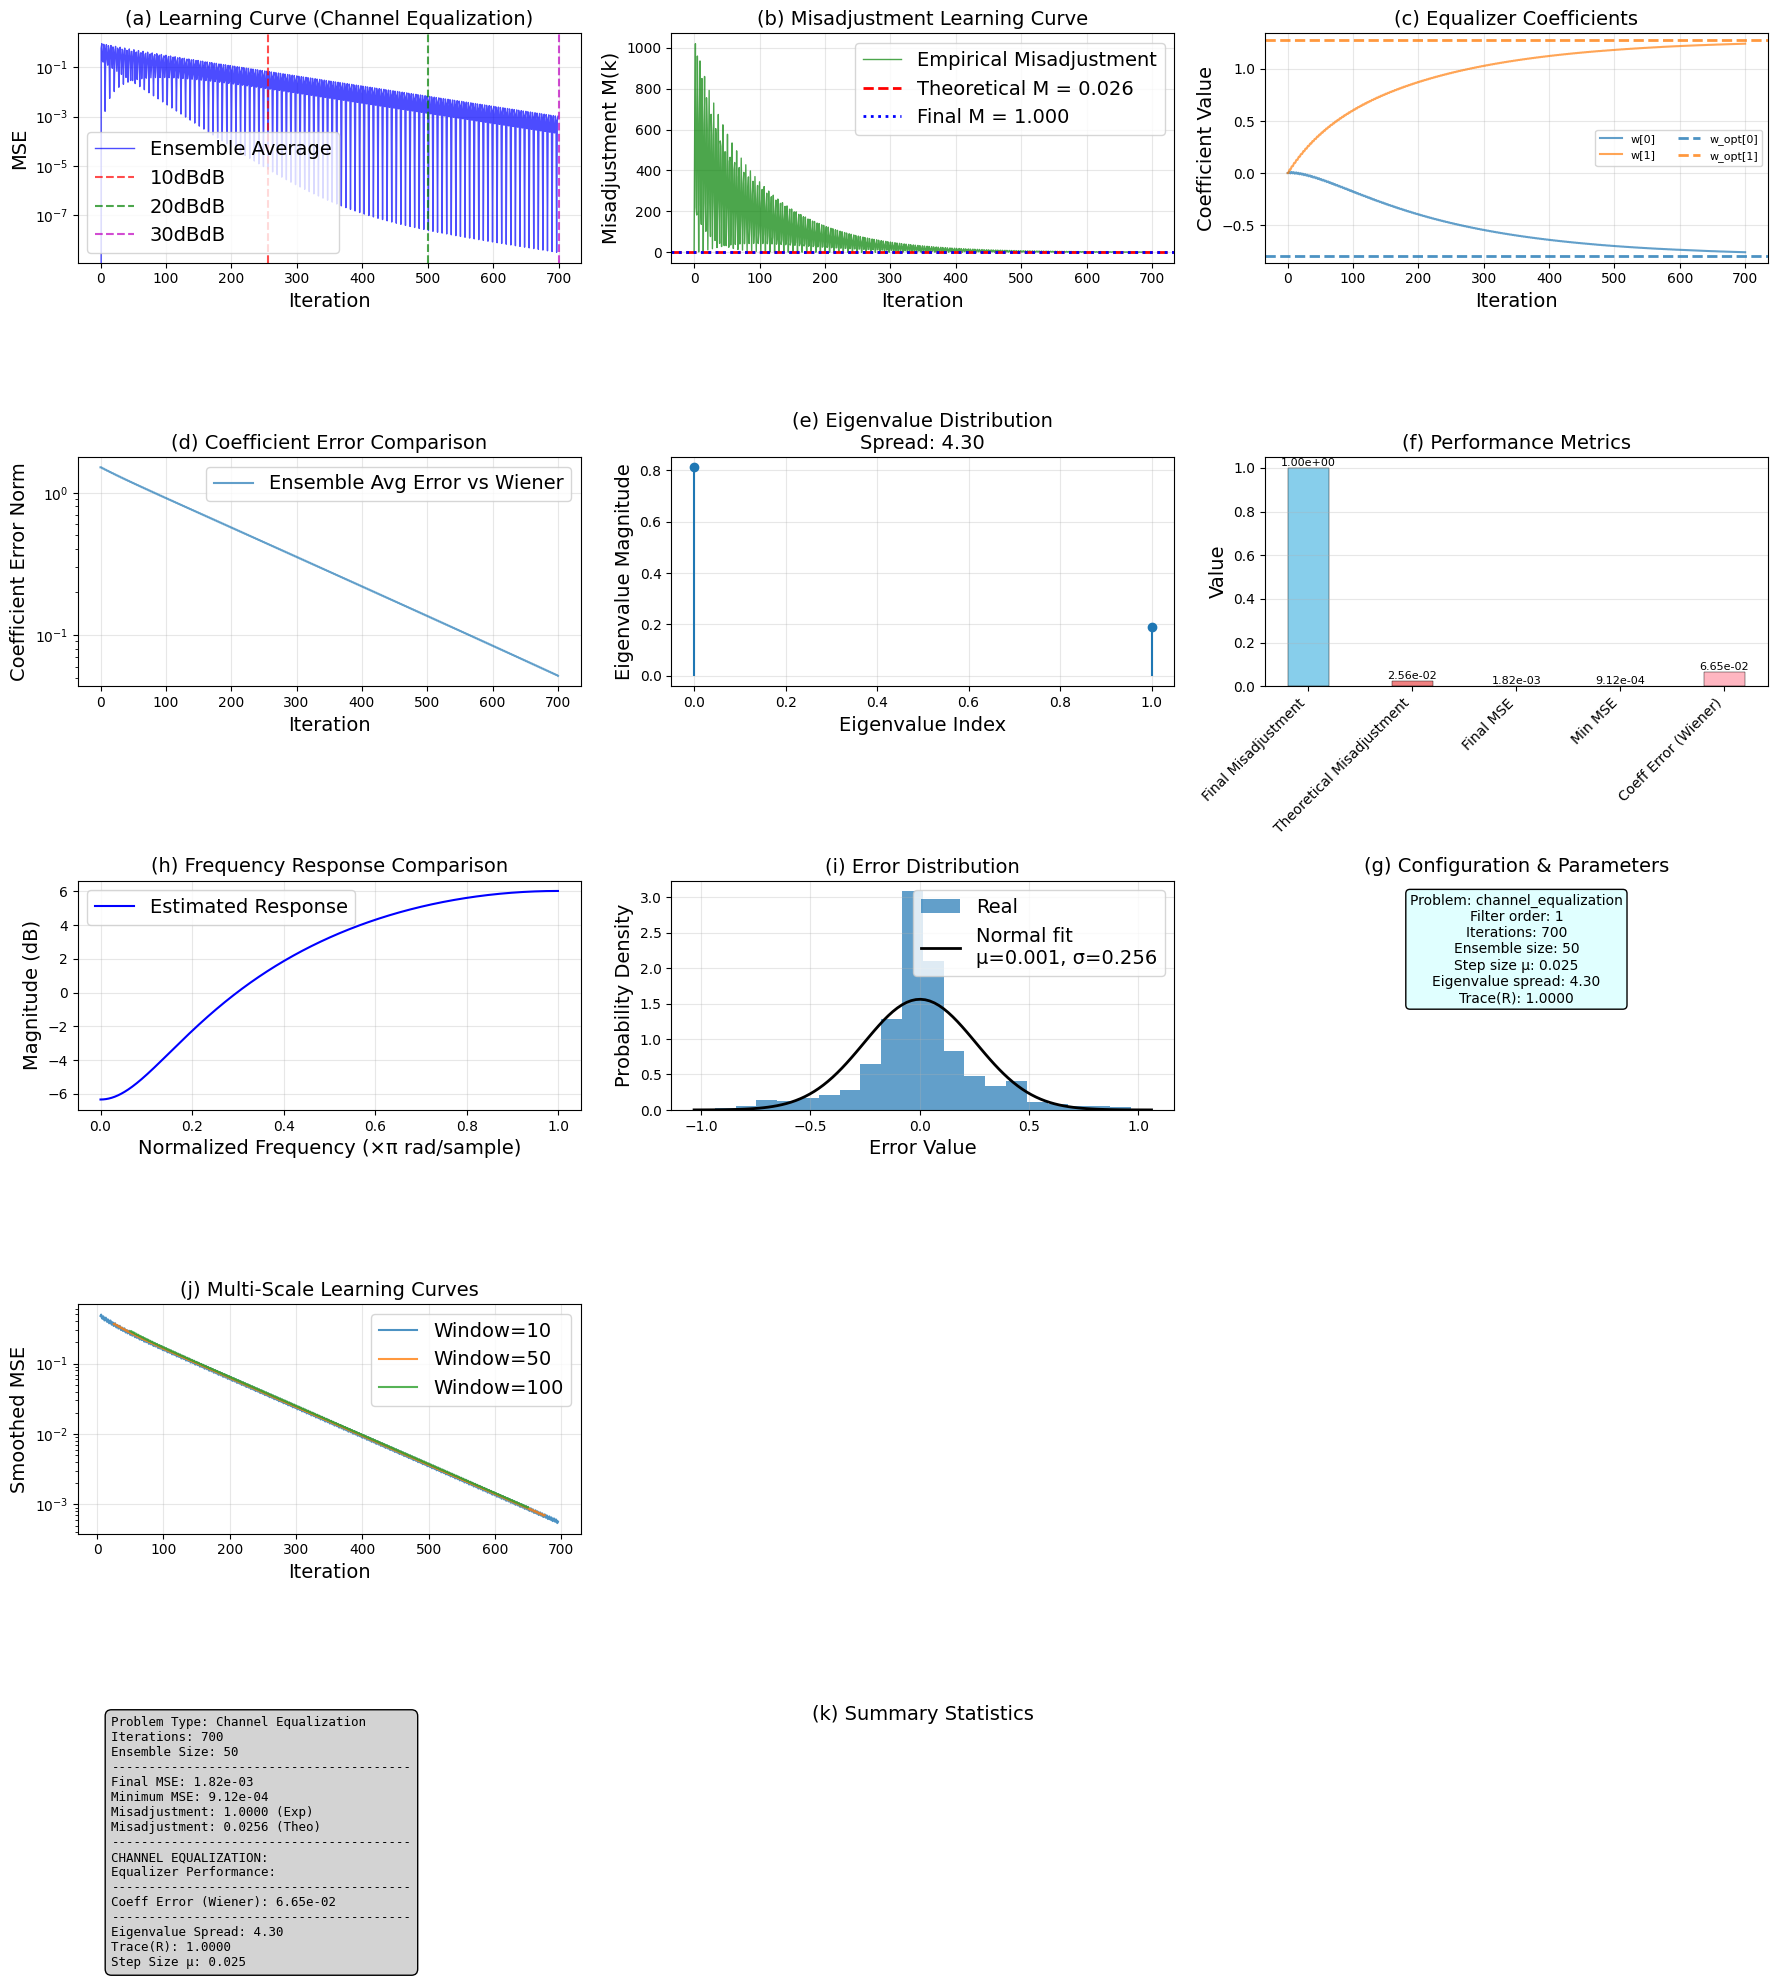

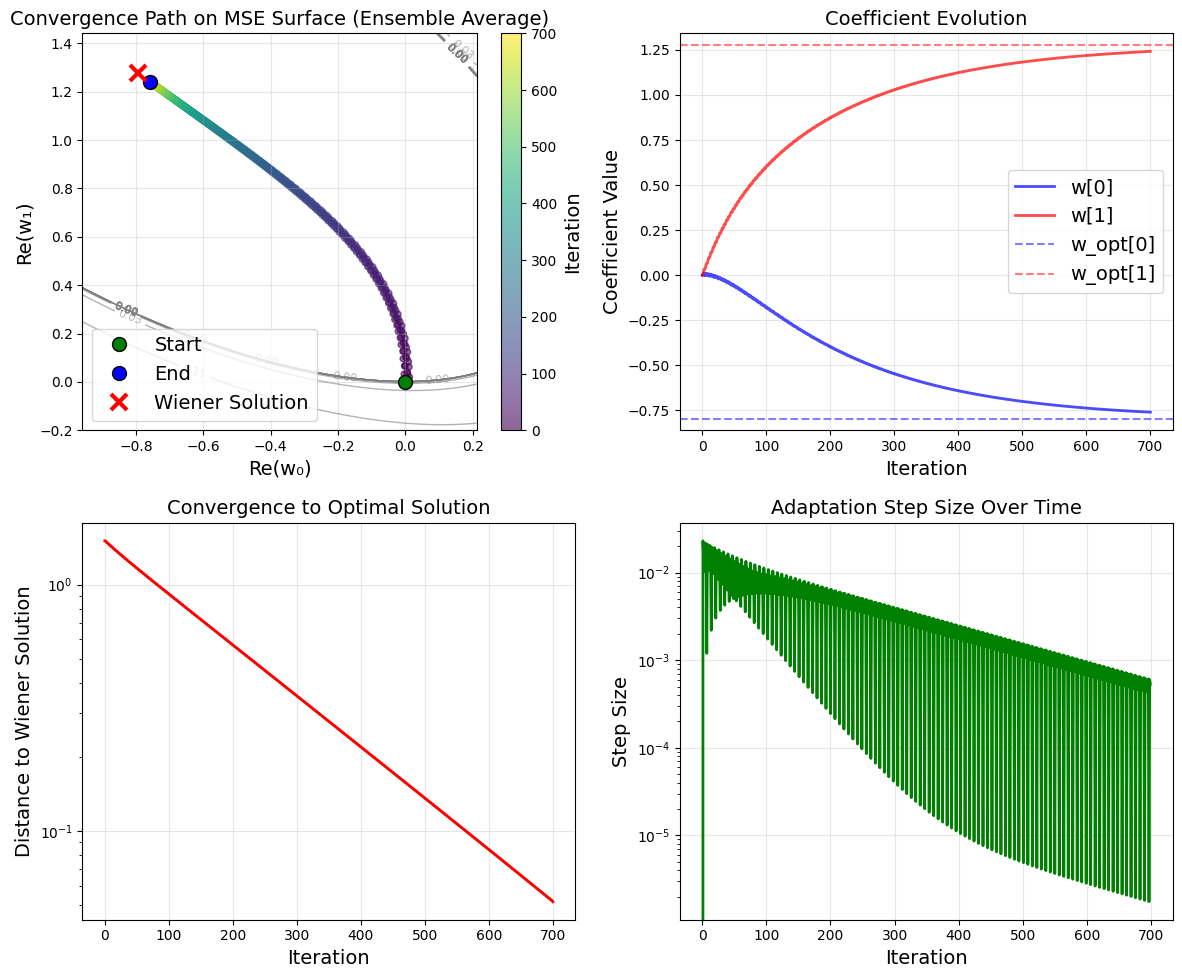

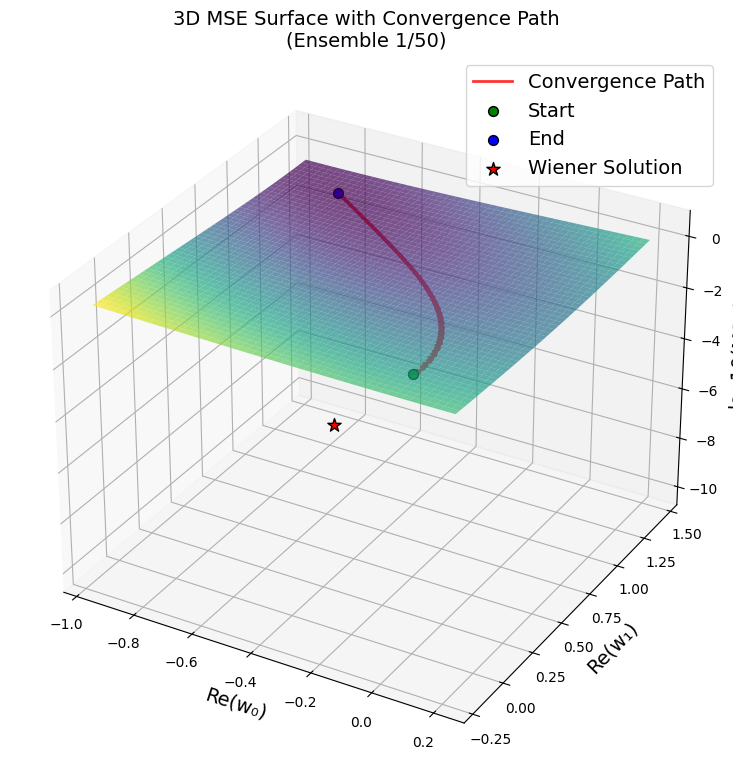

In [4]:
def gen_d_x_fn_example3_2(n_samples: int, key: jax.random.PRNGKey):
    """
    Example 3.2 signal generator: x(k) = cos(ω0 k), d(k) = sin(ω0 k).
    """
    M = 7
    omega0 = 2 * jnp.pi / M
    k = jnp.arange(n_samples, dtype=jnp.float64)

    x = jnp.cos(omega0 * k)
    d = jnp.sin(omega0 * k)

    return x, d
    
def wiener_solution_example3_2(x: jnp.ndarray, d: jnp.ndarray, order: int = 1):
    """
    Example 3.2 Wiener solution using time averages (for deterministic inputs).
    Generalized to filter_order = order (so coefficient length = order + 1).
    
    Args:
      x: input signal (1D array)
      d: desired signal (1D array)
      order: filter order (default 1 → two coefficients)
    
    Returns:
      w_opt: optimal Wiener solution
      R: time-averaged autocorrelation matrix
      p: time-averaged cross-correlation vector
    """
    N = len(x)
    n_coef = order + 1

    if N <= n_coef:
        raise ValueError(f"Need more than {n_coef} samples for time-averaged solution")

    # Build regressor matrix
    # Each row: [x[k], x[k-1], ..., x[k-order]]
    X = jnp.stack([x[order - i:N - i] for i in range(n_coef)], axis=1)
    d_use = d[order:N]  # align desired signal

    # Time-average estimates
    R = (X.conj().T @ X) / (N)
    p = (X.conj().T @ d_use) / (N)

    # Regularization for stability
    R_reg = R + 1e-8 * jnp.eye(n_coef, dtype=x.dtype)
    w_opt = jnp.linalg.solve(R_reg, p)

    return w_opt, R, p

n_samples = 700
n_ensemble = 50
mu = 1.0 / (40 * 1)  # textbook rule (see example 3.3)
lms = jaxfilter.LMS(mu=mu, filter_order=1)
eq = jaxfilter.ChannelEqualization(lms, gen_d_x_fn_example3_2, wiener_sol_fn=wiener_solution_example3_2, n_ensemble=n_ensemble)
lms = jaxfilter.LMS(mu=mu, filter_order=1)
w_hist, e_hist, metrics, _ = eq.run(n_samples)
print("=== Example 3.2 Channel Equalization ===")
print(f"Wiener solution: {metrics['wiener_solution']}")
print(f"R: {metrics['R']}")
print(f"p: {metrics['p']}")
print(f"Final coefficients: {metrics['final_coeff']}")
print(f"Final MSE: {metrics['final_mse']:.6f}")
print(f"Final coeff error: {metrics['final_coeff_error']:.6f}")

# Plot single trial results
fig = jaxfilter.plot_results(w_hist, e_hist, metrics)
save_fig("lms_ex3-2")
# Analyze convergence path (for 2D visualization)
if w_hist.shape[1] >= 2:
  fig = jaxfilter.analyze_convergence_path(w_hist, metrics)
  save_fig("lms_ex3-2-convpath-2d")
fig = jaxfilter.plot_convergence_path_3d(w_hist, metrics)
save_fig("lms_ex3-2-convpath-3d")

#### Example 3.3
- Input: two-tone signal, $x(k) = cos(ω₀k) + cos(ω₁k)$
- Desired: $d(k) = sin(ω₀k) + sin(ω₁k)$
- Use **time averages** for R and p since signal is deterministic.
- Wiener solution: $w_o = \overline{\mathbf R}^{-1}\overline{\mathbf{p}}̄$
- Extends Example 3.2: filter now approximates quadrature relationship for *both* tones.

##### Derivation: Time-averaged Wiener solution (deterministic signals)

**Goal.** For deterministic (non-WSS) inputs we replace ensemble expectations by time averages and obtain the Wiener (least–squares) solution as example 3.2
$$
\overline{\mathbf w} \;\approx\; \overline{\mathbf R}^{-1}\,\overline{\mathbf p},
$$
where
$$
\overline{\mathbf R} \;=\; \overline{\mathbf x(k)\mathbf x^T(k)} 
\;=\; \lim_{N\to\infty}\frac{1}{N}\sum_{k=0}^{N-1}\mathbf x(k)\mathbf x^T(k),
\qquad
\overline{\mathbf p} \;=\; \overline{d(k)\mathbf x(k)}
\;=\; \lim_{N\to\infty}\frac{1}{N}\sum_{k=0}^{N-1}d(k)\,\mathbf x(k).
$$

Below is a self-contained derivation for wiener solution (optimal solution) 

---
##### Derivation of the time-averaged LMS update — equation (3.83)

We use the LMS update in the textbook $2\mu$ form (real-valued signals for simplicity):
$$
\mathbf{w}(k+1) = \mathbf{w}(k) + 2\mu e(k) \mathbf{x}(k),
\qquad
e(k) = d(k) - \mathbf{w}^T(k) \mathbf{x}(k).
$$
Expanding the update gives the algebraically equivalent form
$$
\mathbf{w}(k+1) = \big[\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)\big] \mathbf{w}(k) + 2\mu d(k) \mathbf{x}(k).
\tag{1}
$$

---

##### 1. Define the moving average (over $M$ samples)

For any time sequence $\mathbf{a}(k)$, define the $M$-point (backward) time average
$$
\overline{\mathbf{a}}(k) \equiv \frac{1}{M} \sum_{m=0}^{M-1} \mathbf{a}(k-m).
\tag{2}
$$

(If $\mathbf{a}(k)$ is $M$-periodic, then $\mathbf{a}(k)$ is independent of $k$

---

##### 2. Apply the update to shifted time indices and average

Write the update (1) for the $M$ shifted times $t = k - m$, $m = 0, \dots, M-1$:
$$
\mathbf{w}(k - m + 1) = \big[\mathbf{I} - 2\mu \mathbf{x}(k - m) \mathbf{x}^T(k - m)\big] \mathbf{w}(k - m) + 2\mu d(k - m) \mathbf{x}(k - m).
$$

Average both sides over $m = 0, \dots, M-1$ and use the linearity of the sum:
$$
\frac{1}{M} \sum_{m=0}^{M-1} \mathbf{w}(k - m + 1) = \frac{1}{M} \sum_{m=0}^{M-1} \big[\mathbf{I} - 2\mu \mathbf{x}(k - m) \mathbf{x}^T(k - m)\big] \mathbf{w}(k - m) + \frac{1}{M} \sum_{m=0}^{M-1} 2\mu d(k - m) \mathbf{x}(k - m).
\tag{3}
$$

By definition of the moving average (2), the left-hand side is $\mathbf{w}(k + 1)$. Thus, we obtain the exact averaged-update identity:

$$
\boxed{
\overline{\mathbf{w}}(k + 1) = \frac{1}{M} \sum_{m=0}^{M-1} \big[\mathbf{I} - 2\mu \mathbf{x}(k - m) \mathbf{x}^T(k - m)\big] \mathbf{w}(k - m) + \frac{1}{M} \sum_{m=0}^{M-1} 2\mu d(k - m) \mathbf{x}(k - m)
}
\tag{3.83}
$$

Equivalently, using the overline shorthand,
$$
\boxed{
\overline{\mathbf{w}}(k + 1) = \overline{\big[\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)\big] \mathbf{w}(k)} + \overline{2\mu d(k) \mathbf{x}(k)}
}
\tag{3.83'}
$$

This is an **exact** identity (no approximations yet): it simply averages the shifted, exact updates.

---

##### 3. Usual approximation (decoupling / slow-variation)

To make (3.83) useful, we often assume the filter coefficients vary **slowly** over the averaging window (small step size $\mu$, so that $\mathbf{w}(k - m) \approx \overline{\mathbf{w}}(k)$ for $m = 0, \dots, M-1$. Under this **slow-variation** (or quasi-stationarity) assumption, we can move $\mathbf{w}$ outside the time-average of the multiplicative term:

$$
\overline{\big[\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)\big] \mathbf{w}(k)} \approx \Big(\overline{\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)}\Big) \overline{\mathbf{w}}(k).
$$

Because $\mathbf{I}$ is constant and the averaging operator is linear,
$$
\overline{\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)} = \mathbf{I} - 2\mu \overline{\mathbf{x}(k) \mathbf{x}^T(k)} = \mathbf{I} - 2\mu \overline{\mathbf{R}},
$$
where we define the time-averaged autocorrelation matrix
$$
\overline{\mathbf{R}} = \overline{\mathbf{x}(k) \mathbf{x}^T(k)}.
$$

Similarly,
$$
\overline{2\mu d(k) \mathbf{x}(k)} = 2\mu \overline{d(k) \mathbf{x}(k)} \equiv 2\mu \overline{\mathbf{p}}.
$$

Thus, under the slow-variation approximation, (3.83) becomes
$$
\overline{\mathbf{w}}(k + 1) \approx \big(\mathbf{I} - 2\mu \overline{\mathbf{R}}\big) \overline{\mathbf{w}}(k) + 2\mu \overline{\mathbf{p}}.
\tag{4}
$$

---

##### 4. Steady state and the time-average Wiener solution

At steady state (or for fixed point of the averaged recursion), set $\mathbf{w}(k + 1) = \mathbf{w}(k) = \mathbf{w}$ in (4):
$$
\overline{\mathbf{w}} = \big(\mathbf{I} - 2\mu \overline{\mathbf{R}}\big) \overline{\mathbf{w}} + 2\mu \overline{\mathbf{p}}.
$$

Rearrange:
$$
2\mu \overline{\mathbf{R}} \overline{\mathbf{w}} = 2\mu \overline{\mathbf{p}} \quad \Longrightarrow \quad \overline{\mathbf{R}} \overline{\mathbf{w}} = \overline{\mathbf{p}}.
$$

Provided $\overline{\mathbf{R}}$ is invertible,
$$
\boxed{\quad \overline{\mathbf{w}} = \overline{\mathbf{R}}^{-1} \overline{\mathbf{p}} \quad}
$$
which is the **time-averaged Wiener (least-squares) solution** used for deterministic or periodic inputs.

---

##### 5. Remarks and assumptions

- (3.83) is exact (no approximations); it is simply the average of the exact single-step updates.  
- The step from (3.83) to (4) **requires** the quasi-stationarity/slow-variation assumption (or equivalently that the coefficient vector is almost constant over the averaging window). This is typically justified when $\mu$ is small.  
- If $x(k)$ is periodic with period $M$, then $\overline{\mathbf{R}}$ and $\overline{\mathbf{p}}$ are simply the averages over one period and are time invariant.  
- If $\overline{\mathbf{R}}$ is singular (e.g., single-tone narrowband with filter length large), the inverse is replaced by a pseudo-inverse, and the solution is not unique.

---

**Conclusion.** (3.83) is obtained by averaging the per-time LMS updates. Under slow weight variation, we factor averages and obtain the averaged linear recursion (4), whose fixed point is the time-average Wiener solution $\overline{\mathbf{w}} = \overline{\mathbf{R}}^{-1} \overline{\mathbf{p}}.$


### Example 3.6: System Identification Simulations

**Setup:**
- System to identify: FIR filter with impulse response $\mathbf{h} = [0, 1.0, 3.0, 0, -0.2, -0.4, -0.7, -0.4, -0.2]^T$.
- Adaptive filter order: 8 coefficients (matches length of $\mathbf{h}$).
- Input signal: Colored noise with variance $\sigma_x^2 = 1$ and eigenvalue spread, or Gaussian white noise uncorrelated with input (cases vary).
- Measurement noise: Gaussian white noise with variance $\sigma_n^2$ (specified per case).
- LMS update: $\mathbf{w}(k + 1) = \mathbf{w}(k) + 2\mu e(k) \mathbf{x}(k)$, where $e(k) = d(k) - \mathbf{x}^T(k) \mathbf{w}(k)$.

#### (a) Run Algorithm and Comment on Convergence Behavior
- Run LMS for three cases (colored noise with variance $\sigma_x^2 = 1$ and eigenvalue spreads 10, 20, 80).
- Comment on convergence: Faster convergence expected with smaller eigenvalue spread (e.g., 10) due to reduced condition number of $\mathbf{R}$. Slower convergence with spread 80 due to increased eigenvalue disparity.

#### (b) Measure Misadjustment and Compare with Theoretical Results
- Misadjustment $M = \frac{\mu \text{tr}[\mathbf{R}]}{1 - \mu \text{tr}[\mathbf{R}]}$ (from 3.50).
- For white input, $\text{tr}[\mathbf{R}] = 10 \sigma_x^2 = 10$. Choose $\mu$ to ensure stability ($\mu \text{tr}[\mathbf{R}] < 1$).
- Simulate and compare $M$ with theory. Expected $M \approx \mu \cdot 10$ for small $\mu$ (e.g., $\mu = 0.01$ gives $M \approx 0.1$).

#### (c) Fixed-Point Arithmetic Effects
- Case: $\sigma_n^2 = 0.0015$, coefficient wordlength $b_c = 16$ bits, signal wordlength $b_x = 16$ bits.
- Run experiments, calculate expected $\|\Delta \mathbf{w}(k)\|^2$ and $\xi(k)$:
  - $\|\Delta \mathbf{w}(k)\|^2$: Error due to finite precision, proportional to $2^{-2b_c}$.
  - $\xi(k)$: Excess MSE, includes noise and quantization effects.
- Expected values depend on $\mu$; use small $\mu$ (e.g., $\mu = 0.001$) to minimize instability.

#### (d) Repeat Experiment with Different Wordlengths
- Cases: $b_c = 12$ bits, $b_d = 12$ bits; $b_c = 10$ bits, $b_d = 10$ bits.
- Repeat (c) simulations, expecting increased $\|\Delta \mathbf{w}(k)\|^2$ and $\xi(k)$ with reduced wordlength due to larger quantization errors.

#### (e) Time-Varying System Identification
- System: Time-varying with coefficients as first-order Markov processes, $\lambda_w = 0.99$.
- Input: Gaussian white noise with variance $\sigma_x^2 = 1.0$.
- Measurement noise: Gaussian white noise with variance $\sigma_n^2 = 0.01$.
- Initial $\sigma_w^2 = 0.0015$.
- Simulate, measure total excess MSE $\xi_{\text{total}}$, and compare to calculated:
  - Theoretical $\xi_{\text{total}} \approx \mu \text{tr}[\mathbf{R}] \cdot \sigma_n^2 + \frac{\sigma_n^2}{1 - \mu \lambda_{\max}}$ (for small $\mu$).
  - With $\mu = 0.01$, $\text{tr}[\mathbf{R}] = 10$, $\lambda_{\max} = 1$:
    $$
    \xi_{\text{total}} \approx 0.01 \cdot 10 \cdot 0.01 + \frac{0.01}{1 - 0.01} \approx 0.001 + 0.0101 \approx 0.0111.
    $$
  - Adjust $\mu$ (e.g., $\mu = 0.001$) for stability with time-varying case: $\xi_{\text{total}} \approx 0.0001 + 0.01001 \approx 0.01011$.

Step size (μ): 0.0128
Filter length (N): 8
Input power (σ_x²): 1.0
Stability check - μ * N * σ_x²: 0.1024
Should be < 1 for convergence: True
=== Example 3.6.2 Sytem Identification (a,b) ===
Wiener solution: [ 1.00367171e-01  3.00230617e-01 -2.84283289e-04 -2.00408499e-01
 -3.99859615e-01 -6.99045355e-01 -3.99465705e-01 -2.01112470e-01]
Final coefficients: [ 0.10427812  0.29313312  0.00433053 -0.19877159 -0.40622691 -0.69311445
 -0.4035189  -0.19923938]
Final MSE: 0.000152
Min MSE: 0.000100
Misadjustment(Experiment): 0.525285
Misadjustment(Theory) 0.2410710950964753
Final coeff error: 0.018581

=== CONVERGENCE ANALYSIS (Ensemble Average) ===
Total iterations: 473
Initial coefficients: w0=0.0000, w1=0.0000
Final coefficients: w0=0.1043, w1=0.2931
Wiener solution: w0=0.1004, w1=0.3002
Final distance to Wiener solution: 0.008104
Total path length: 0.3801
Average step size: 0.000805


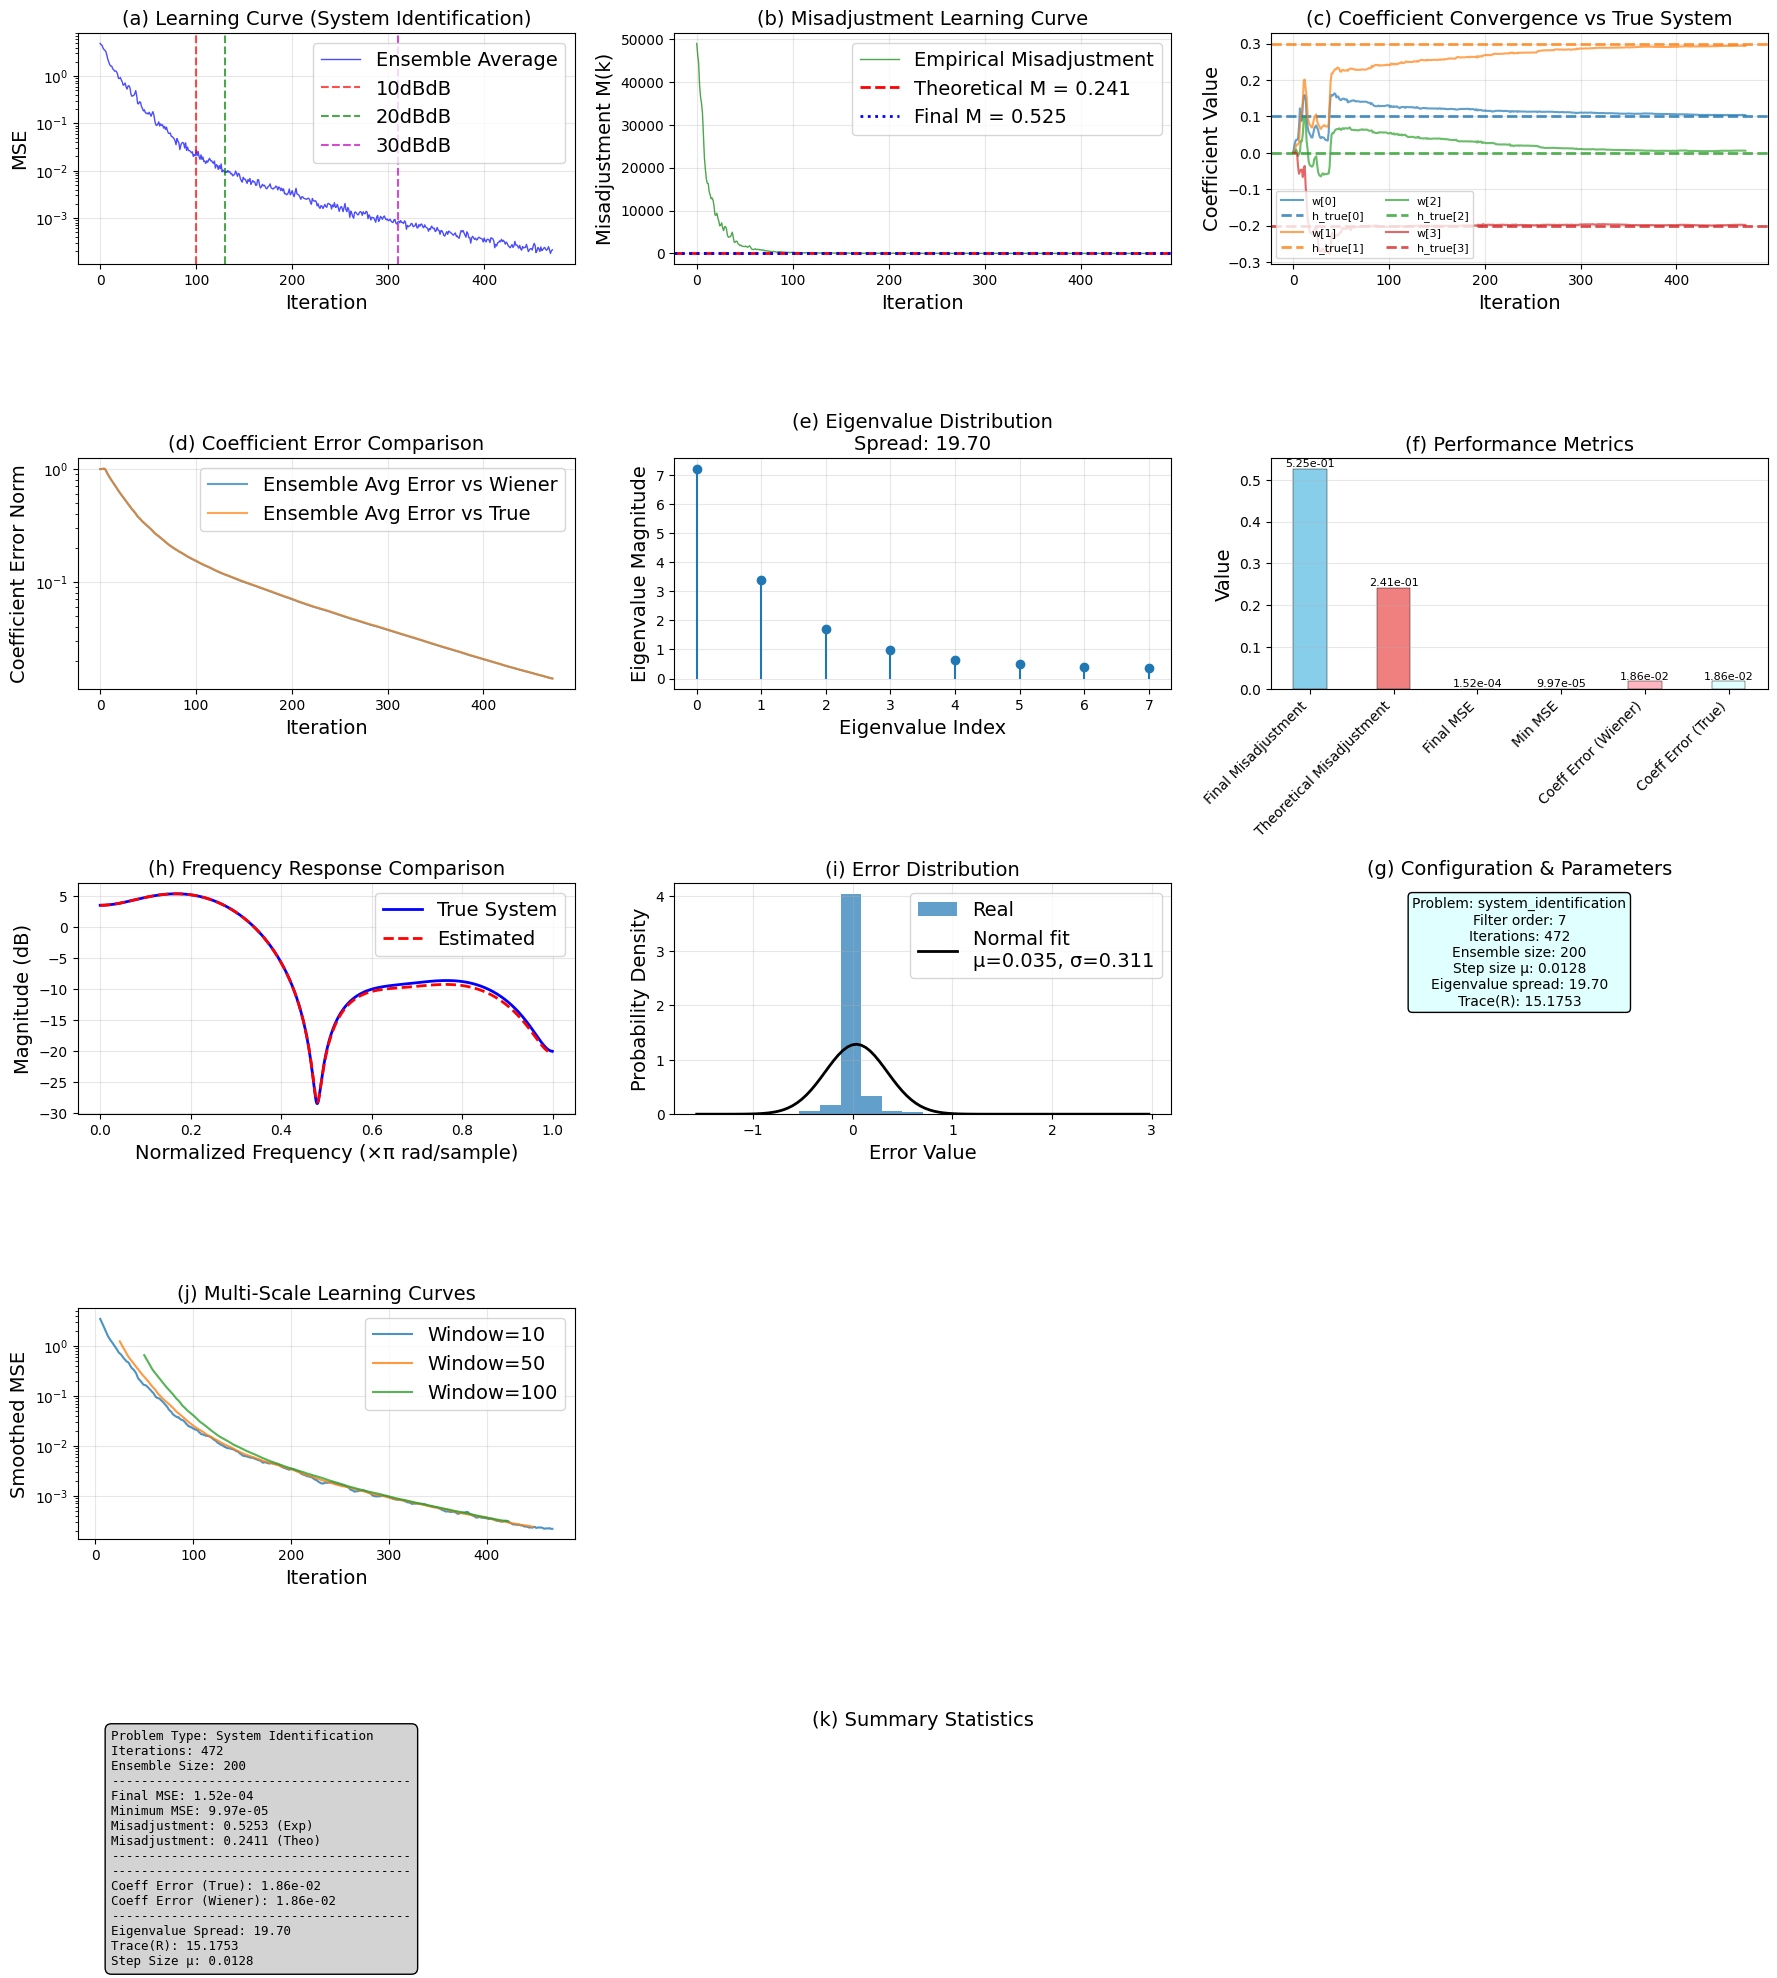

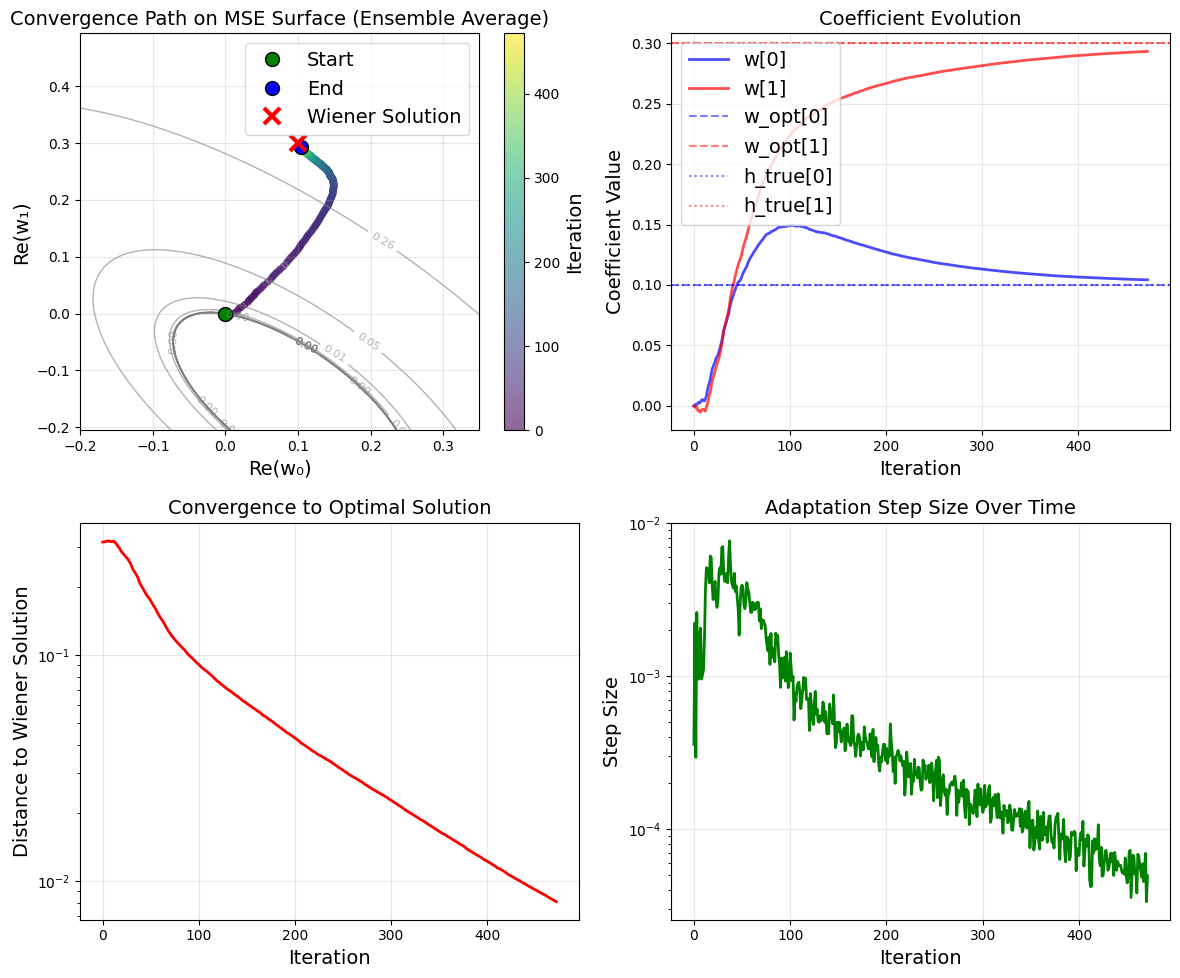

In [5]:
# Fixed JAX-compatible signal generation function
def gen_d_x_example3_6_2_a(n_samples: int, a: float, key: jax.random.PRNGKey, sigma_x2: float = 1, sigma_n2: float = 1e-4):
    """Create x via AR(1) with pole a, produce desired d = h_true * x + measurement noise."""
    key, subkey1, subkey2 = jax.random.split(key, 3)
    h_true = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=jnp.float64)
    
    # White Gaussian noise
    u = jax.random.normal(subkey1, (n_samples + 100,), dtype=jnp.float64) * jnp.sqrt(sigma_x2)
    
    # Generate AR(1) signal using JAX-compatible operations
    def ar1_step(carry, u_val):
        x_prev = carry
        x_current = a * x_prev + u_val
        return x_current, x_current
    
    # Initialize with first value and scan through the rest
    x0 = jnp.array(0.0, dtype=jnp.float64)
    _, x = jax.lax.scan(ar1_step, x0, u[1:])
    
    # Prepend the initial value
    x = jnp.concatenate([jnp.array([x0]), x])
    
    # Filter with plant h_true (FIR)
    d = jnp.convolve(x, h_true, mode='full')[:len(x)]
    
    # Generate measurement noise (return this for min MSE calculation)
    measurement_noise = jax.random.normal(subkey2, d.shape) * jnp.sqrt(sigma_n2)
    
    # Add measurement noise
    d = d + measurement_noise
    
    # Remove transients
    start = 100
    return h_true, x[start:start+n_samples], d[start:start+n_samples], measurement_noise[start:start+n_samples]
    
# Example 3.6 signal generator with spread control
def create_example3_6_2_a_generator(target_spread: float = 1.0, sigma_x2:float = 1.0, sigma_n2: float = 1e-4):
    """Create signal generator for Example 3.6 with specific eigenvalue spread"""
    def generator(n_samples: int, key: jax.random.PRNGKey):
        # Find AR(1) pole for target spread
        a = jaxfilter.find_ar1_pole_for_spread_theoretical(target_spread, 8)  # 8-tap system
        return gen_d_x_example3_6_2_a(n_samples, a, key, sigma_x2=sigma_x2, sigma_n2=sigma_n2)
    return generator
    
# Parameters
n_ensemble  = 200
n_samples   = 472
h_true = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=float)
filter_order = len(h_true) - 1
mu     = 0.0128
sigma_n2 = 1e-4
sigma_x2 = 1.0
target_spread=20
lms = jaxfilter.LMS(mu=mu, filter_order=filter_order)
 
# For part (a) - different spreads
#for spread in [1.0, 20.0, 80.0]:
gen_signals_fn = create_example3_6_2_a_generator(
    target_spread=target_spread, 
    sigma_x2=sigma_x2, 
    sigma_n2=sigma_n2
)
sysid = jaxfilter.SystemIdentification(
    lms, 
    gen_signals_fn, 
    n_ensemble = n_ensemble
)
w_hist, e_hist, metrics, meansured_noise = sysid.run(n_samples=n_samples)

R = metrics["R"]
# Add debugging to check your parameters
print(f"Step size (μ): {mu}")
print(f"Filter length (N): {len(h_true)}")
print(f"Input power (σ_x²): {sigma_x2}")
print(f"Stability check - μ * N * σ_x²: {mu * len(h_true) * sigma_x2}")
print(f"Should be < 1 for convergence: {mu * len(h_true) * sigma_x2 < 1}")

N = filter_order  # This should be 8
print("=== Example 3.6.2 Sytem Identification (a,b) ===")
print(f"Wiener solution: {metrics['wiener_solution']}")
print(f"Final coefficients: {metrics['final_coeff']}")
print(f"Final MSE: {metrics['final_mse']:.6f}")
print(f"Min MSE: {metrics['min_mse']:.6f}")
print(f"Misadjustment(Experiment): {metrics['misadjustment']:.6f}")
misadjustment_theory = metrics['misadjustment_theoretical']
print(f"Misadjustment(Theory) {misadjustment_theory}")
print(f"Final coeff error: {metrics['final_coeff_error']:.6f}")

# Plot single trial results
fig = jaxfilter.plot_results(w_hist, e_hist, metrics)
save_fig("lms_ex3-6-2-ab")

# Analyze convergence path (for 2D visualization)
if w_hist.shape[1] >= 2:
  fig = jaxfilter.analyze_convergence_path(w_hist, metrics)
  save_fig("lms_ex3-6-2-ab-convpath-2d")

(c), (d) The LMS algorithm is implemented employing fixed-point arithmetic using 16, 12, and 10 bits for data and coefficient wordlengths. The chosen value of $\mu$ is $0.01$. The learning curves for the MSE are depicted in Figures below, depicting the evolution of $||\Delta\mathbf{w}(k)||_Q^2$ with the number of iterations. The experimental results show that the algorithm still works for such limited precision. In Table 3.2, we present a summary of the results obtained from simulation experiments and a comparison with the results predicted by the theory. The experimental results are obtained by averaging the results of 200 independent runs. The relations employed to calculate the theoretical results shown in Table\,3.2 correspond to (B.26) and (B.32) derived in Appendix B. These relations are repeated here for convenience:
$$
\mathbb{E}[||\Delta\mathbf{w}(k)||_Q^2] = \frac{\mu(\sigma_n^2 + \sigma_e^2)(N+1)}{1-\mu(N+1)\sigma_x^2} + \frac{(N+1)\sigma_{\mathbf{w}}^2}{4\mu\sigma_x^2[1-\mu(N+1)\sigma_x^2]}
$$
$$
\xi(k)_Q = \frac{\sigma_e^2 + \sigma_n^2}{1-\mu(N+1)\sigma_x^2} + \frac{(N+1)\sigma_{\mathbf{w}}^2}{4\mu\sigma_x^2[1-\mu(N+1)\sigma_x^2]}
$$

Step size (μ): 0.01
Filter length (N): 8
Input power (σ_x²): 1.0
Stability check - μ * N * σ_x²: 0.08
Should be < 1 for convergence: True
=== Example 3.6.2 Sytem Identification Fixed Point ===
Wiener solution: [ 1.10209243e-01  3.30225212e-01 -4.92266762e-04 -2.19931912e-01
 -4.40074994e-01 -7.70010252e-01 -4.39587037e-01 -2.19788992e-01]
Final coefficients: [ 0.10408429  0.31465585 -0.00114568 -0.21063195 -0.42028488 -0.73598075
 -0.41980907 -0.20972466]
Final MSE: 0.009085
Min MSE: 0.001502
Misadjustment(Experiment): 5.048996
Misadjustment(Theory) 0.0989010989010989
Final coeff error: 0.069232


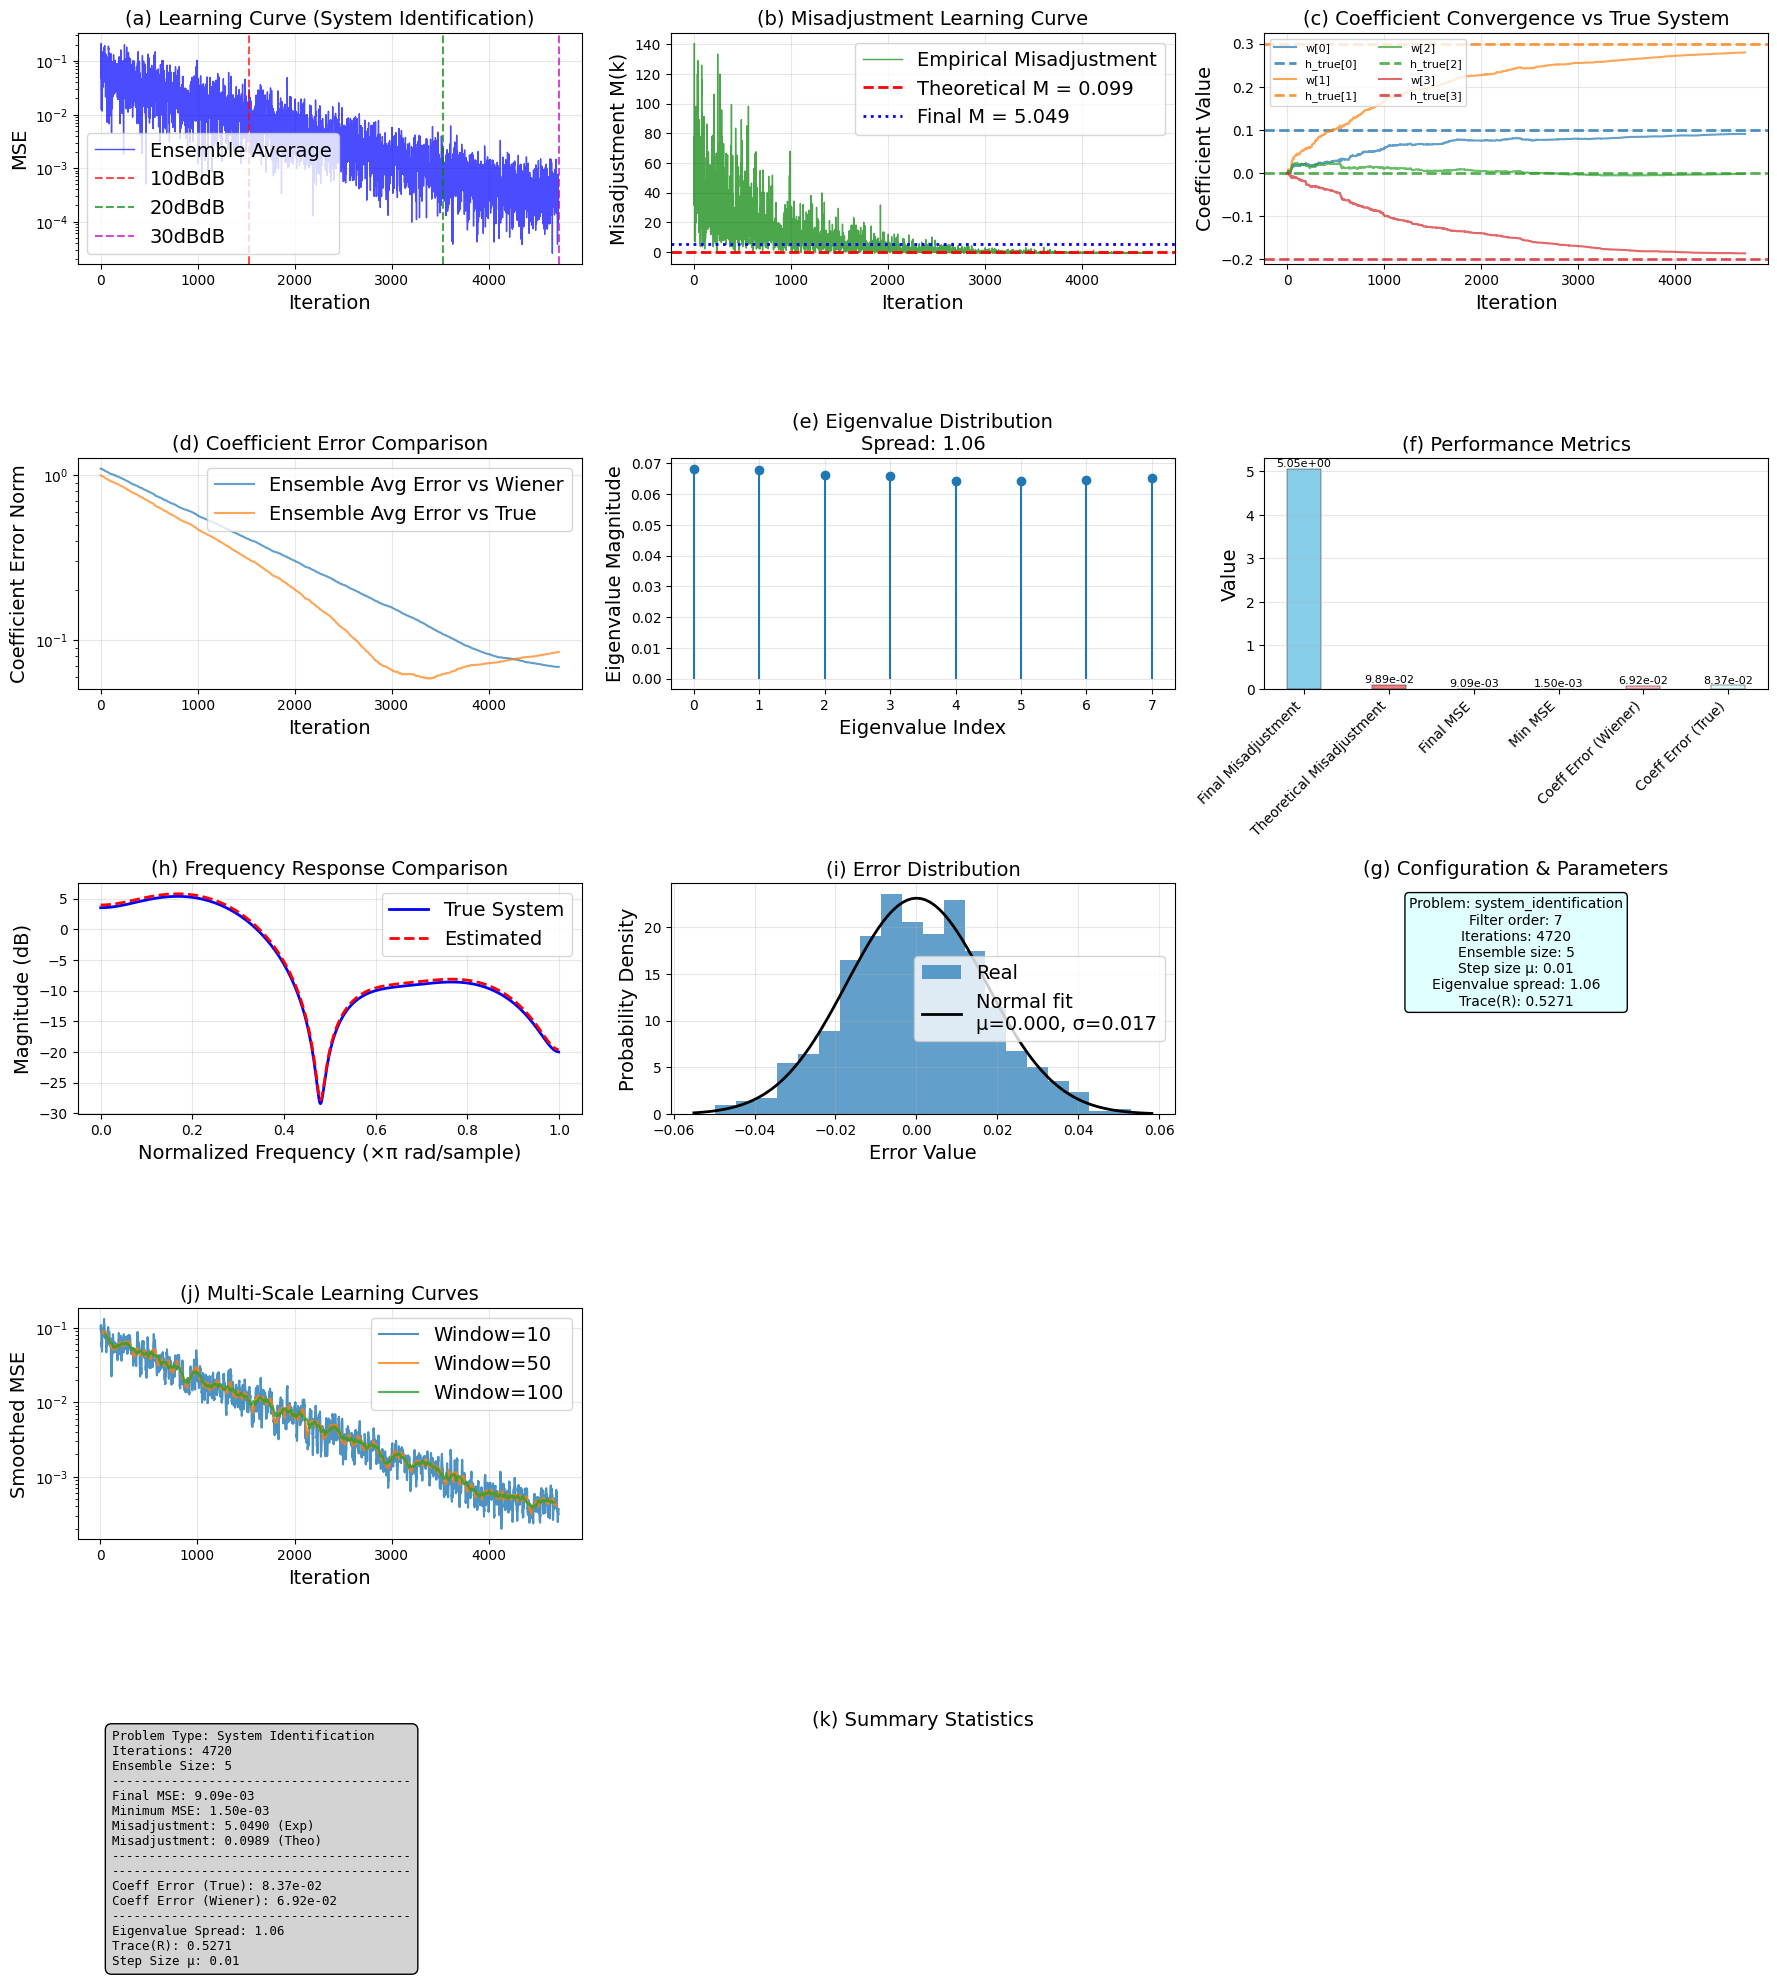

In [6]:
# Fixed version of your original function
def gen_d_x_example3_6_2_cd(n_samples: int, a: float, key: jax.random.PRNGKey, sigma_x2: float = 1, sigma_n2: float = 1e-4, bits = 10):
    """Create x via AR(1) with pole a, produce desired d = h_true * x + measurement noise."""
    key, subkey1, subkey2 = jax.random.split(key, 3)
    h_true = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=jnp.float64)
    
    # White Gaussian noise
    u = jax.random.normal(subkey1, (n_samples + 100,), dtype=jnp.float64) * jnp.sqrt(sigma_x2)
    
    # Generate AR(1) signal using JAX-compatible operations
    def ar1_step(carry, u_val):
        x_prev = carry
        x_current = a * x_prev + u_val
        return x_current, x_current
    
    # Initialize with first value and scan through the rest
    x0 = jnp.array(0.0, dtype=jnp.float64)
    _, x = jax.lax.scan(ar1_step, x0, u[1:])
    
    # Prepend the initial value
    x = jnp.concatenate([jnp.array([x0]), x])
    
    # Filter with plant h_true (FIR)
    d = jnp.convolve(x, h_true, mode='full')[:len(x)]
    
    # Generate measurement noise (return this for min MSE calculation)
    measurement_noise = jax.random.normal(subkey2, d.shape) * jnp.sqrt(sigma_n2)
    
    # Add measurement noise
    d = d + measurement_noise
    
    # Scale signals to fit in fixed-point range [-1, 1]
    # Find scaling factors to prevent overflow
    x_scale = 1.0 / jnp.max(jnp.abs(x)) if jnp.max(jnp.abs(x)) > 1.0 else 1.0
    d_scale = 1.0 / jnp.max(jnp.abs(d)) if jnp.max(jnp.abs(d)) > 1.0 else 1.0
 
    x_scaled = x * x_scale
    d_scaled = d * d_scale
    
    # Quantize scaled signals
    jaxfixed_point_gen = jaxfixedpt.JaxFixedPoint(ibits=1, fbits=bits-1, rmode="nearest")
    x_q = jaxfixed_point_gen.quantize(x_scaled)
    d_q = jaxfixed_point_gen.quantize(d_scaled)
    
    # Remove transients
    start = 100
    return h_true, x_q[start:start+n_samples], d_q[start:start+n_samples], measurement_noise[start:start+n_samples]
    
# Example 3.6 signal generator with spread control
def create_example3_6_2_cd_generator(target_spread: float = 1.0, sigma_x2: float = 1.0, sigma_n2: float = 1e-4, bits: int = 10):
    """Create signal generator for Example 3.6 with specific eigenvalue spread"""
    def generator(n_samples: int, key: jax.random.PRNGKey):
        # Find AR(1) pole for target spread
        a = jaxfilter.find_ar1_pole_for_spread_theoretical(target_spread, 8)  # 8-tap system
        return gen_d_x_example3_6_2_cd(n_samples, a, key, sigma_x2=sigma_x2, sigma_n2=sigma_n2, bits = bits)
    return generator
    
def misadjustment(mu: float, N: int, sigma_x2: float) -> float:
    numerator = mu * (N + 1) * sigma_x2
    denominator = 1 - mu * (N + 1) * sigma_x2
    return numerator / denominator
    
# Parameters
n_samples   = 4720
n_ensemble = 5
h_true = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=float)
filter_order = len(h_true) - 1
mu     = 0.01
sigma_n2 = 0.0015
sigma_x2 = 1.0
bits = 10
target_spread = 1.0
misadjustment_theory = misadjustment(mu, len(h_true), sigma_x2)
lms = jaxfilter.LMS(mu=mu, filter_order=filter_order)
results = {}

# For part (a) - different spreads
#for spread in [1.0, 20.0, 80.0]:
gen_signals_fn = create_example3_6_2_cd_generator(
    target_spread=target_spread, 
    sigma_x2=sigma_x2, 
    sigma_n2=sigma_n2, 
    bits=bits
)

sysid = jaxfilter.SystemIdentification(
    lms, 
    gen_signals_fn, 
    n_ensemble = n_ensemble,
    theoretical_misadjustment_val = misadjustment_theory
)

w_hist, e_hist, metrics, _ = sysid.run(n_samples=n_samples)
trR = metrics['trace_R']
R = trR = metrics['R']
# Add debugging to check your parameters
print(f"Step size (μ): {mu}")
print(f"Filter length (N): {len(h_true)}")
print(f"Input power (σ_x²): {sigma_x2}")
print(f"Stability check - μ * N * σ_x²: {mu * len(h_true) * sigma_x2}")
print(f"Should be < 1 for convergence: {mu * len(h_true) * sigma_x2 < 1}")

print("=== Example 3.6.2 Sytem Identification Fixed Point ===")
print(f"Wiener solution: {metrics['wiener_solution']}")
print(f"Final coefficients: {metrics['final_coeff']}")
print(f"Final MSE: {metrics['final_mse']:.6f}")
print(f"Min MSE: {metrics['min_mse']:.6f}")
print(f"Misadjustment(Experiment): {metrics['misadjustment']:.6f}")
print(f"Misadjustment(Theory) {misadjustment_theory}")
print(f"Final coeff error: {metrics['final_coeff_error']:.6f}")

# Plot single trial results
fig = jaxfilter.plot_results(w_hist, e_hist, metrics)
save_fig("lms_ex3-6-2-cd")

(e) The performance of the LMS algorithm is also tested in the nonstationary environment above described. The excess MSE is measured and depicted in Fig.~3.12. For this example $\mu_{\mathrm{opt}}$ is found to be greater than $\mu_{\mathrm{max}}$. The value of $\mu$ used in the example is calculated by 
$$
\mu_{\text{opt}} = \sqrt{\frac{(N+1)\sigma_w^2}{4\sigma_n^2\text{tr}[\mathbf{R}]}} \quad (3.76)
$$

The excess MSE in steady state predicted by the relation
$$
\xi_{\mathrm{total}} \approx \frac{\mu\sigma_n^2\mathrm{tr}[\mathbf{R}]}{1-\mu\mathrm{tr}[\mathbf{R}]} + \frac{\sigma_{\mathbf{w}}^2}{4\mu}\sum_{i=0}^N \frac{1}{1-\mu\lambda_i}
$$
is $0.124$, whereas the measured excess MSE in steady state is $0.118$. Once more the results obtained from the analysis are accurate.

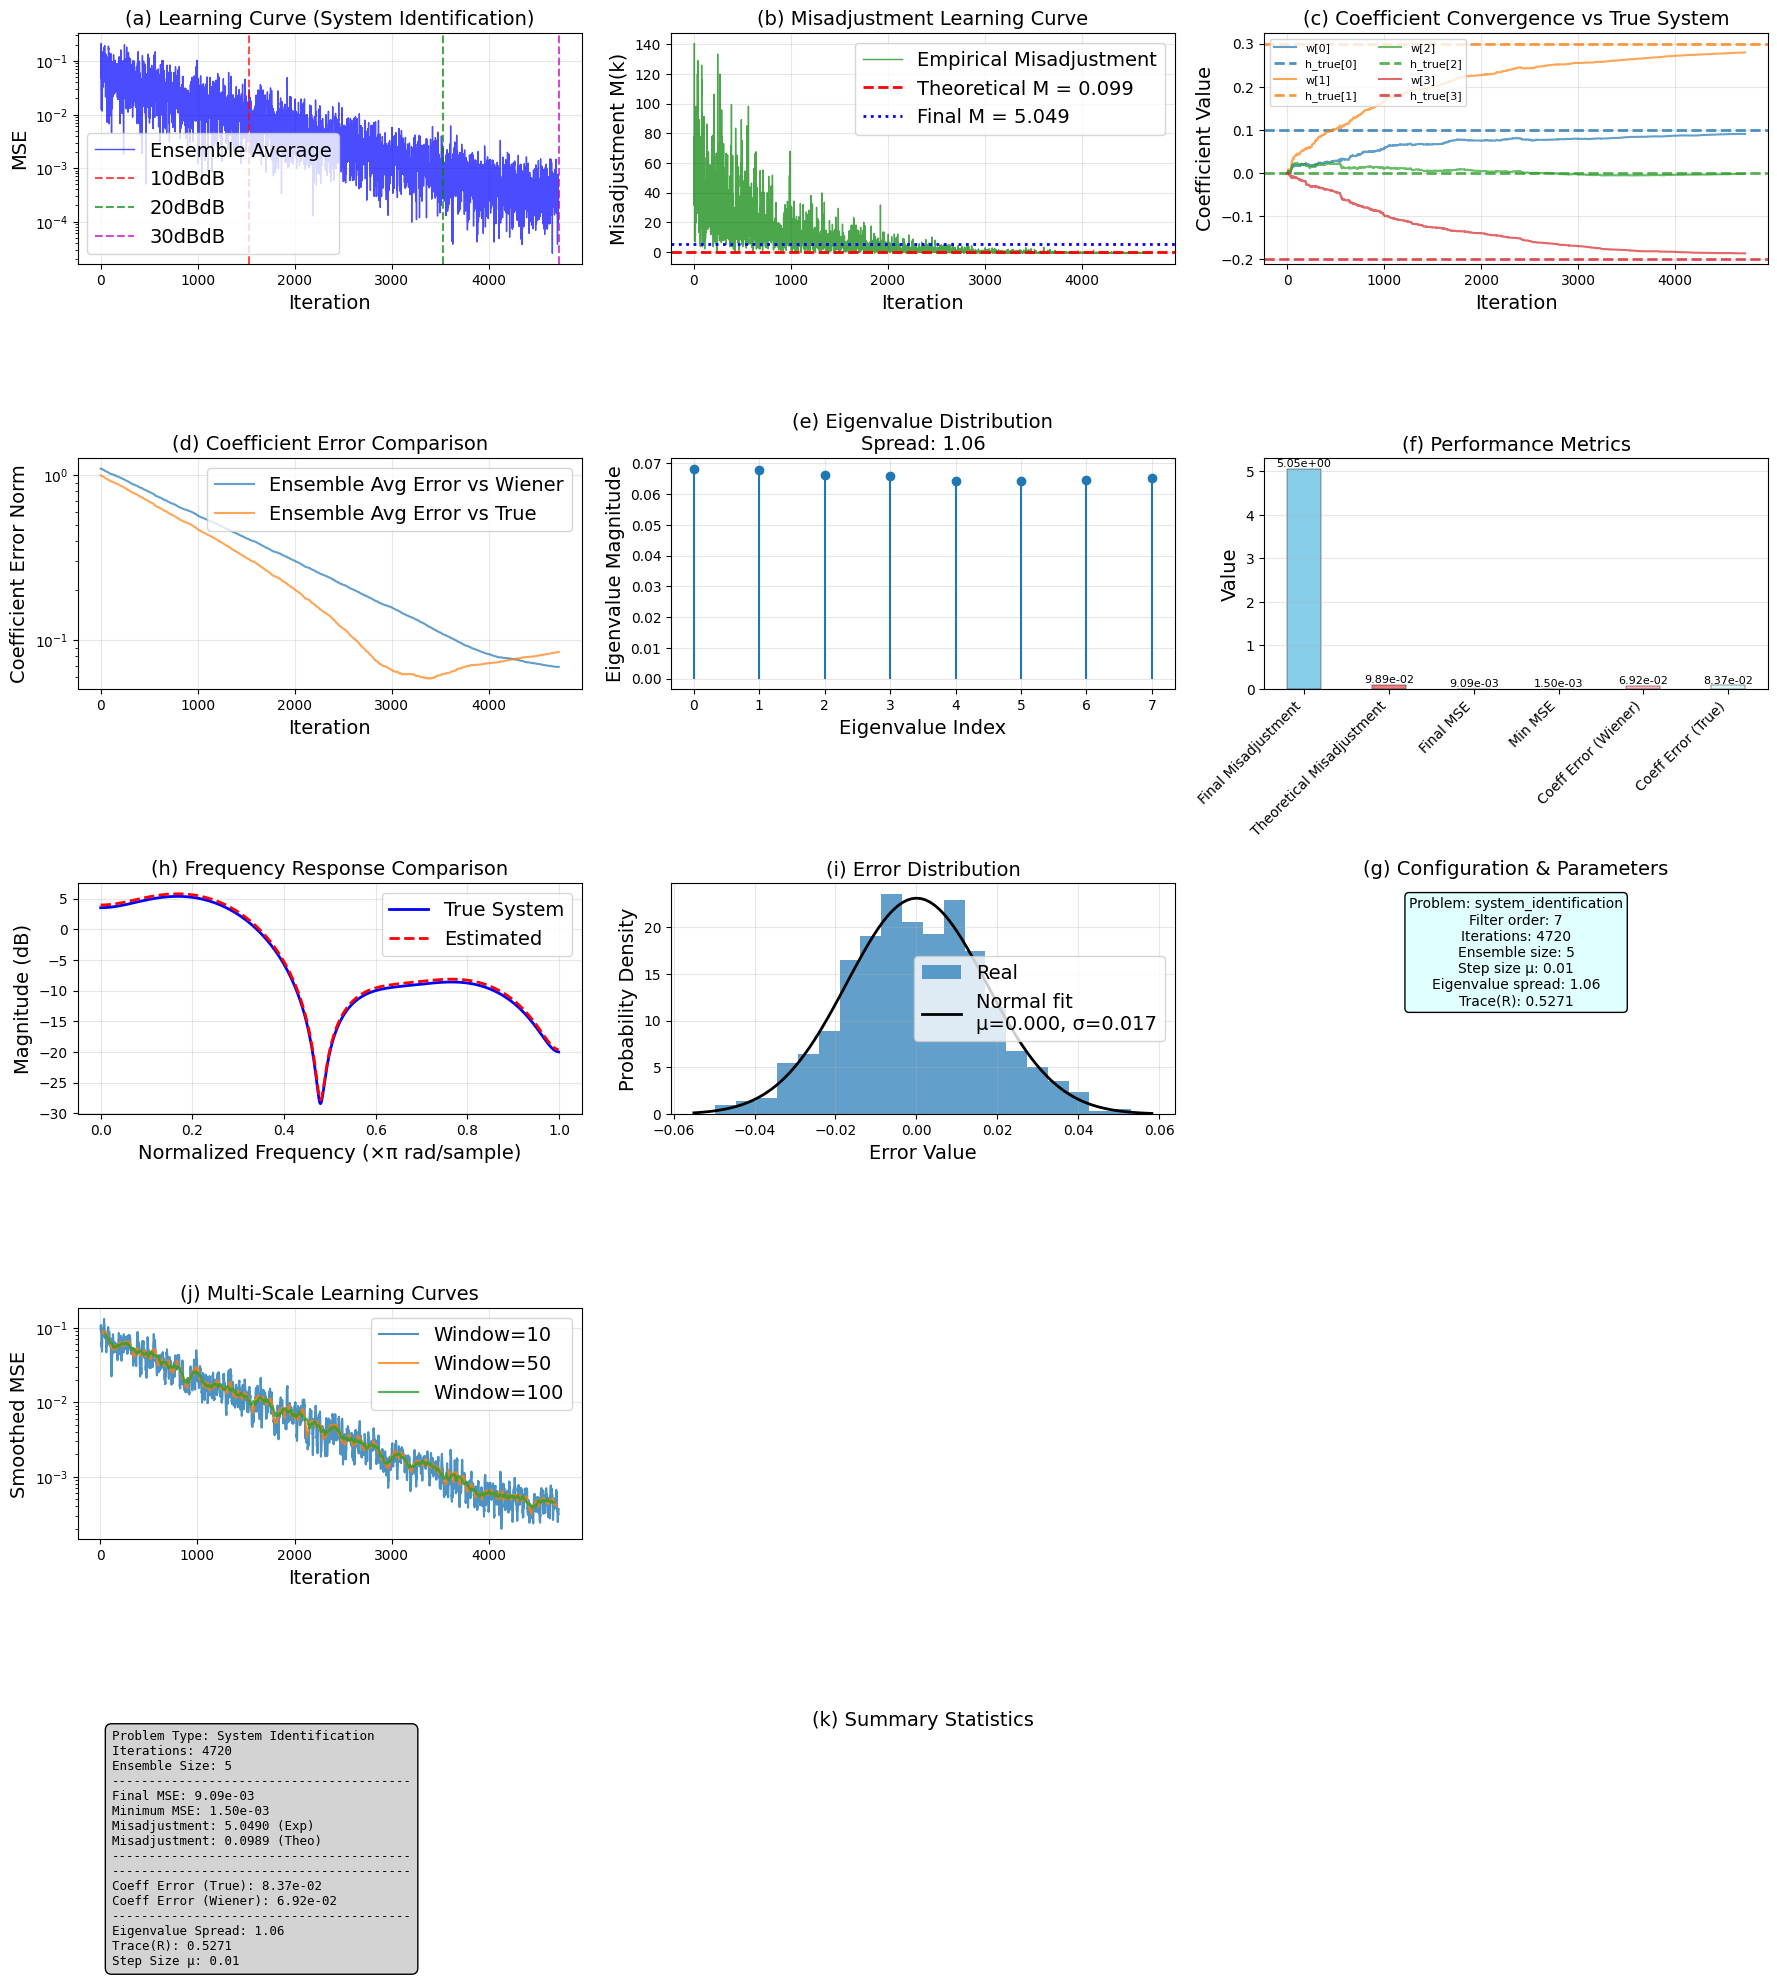

In [7]:
# Plot single trial results
fig = jaxfilter.plot_results(w_hist, e_hist, metrics)
save_fig("lms_ex3-6-2-e")